<a href="https://colab.research.google.com/github/TasnimShaun/Exploratory-Data-Analysis-EDA-and-Feature-Engineering/blob/main/Machine_Learning_Assignment_1_Answer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: MD TASNIMUL HASAN   Email: tasnimshaun3@gmail.com

Question 1
* Load the Titanic dataset and display:


* Dataset shape,
* First 10 rows,
* 5 random samples List item





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sample_data/titanic_data_updated.csv')

# data set shape

print(f"The shape of this data set is {df.shape}")
print(f"Row = {df.shape[0]}")
print(f"column = {df.shape[1]}")

# dataset first 10 row

print(df.head(10))

# dataset 5 random sample

print(df.sample(5))

The shape of this data set is (891, 12)
Row = 891
column = 12
   PassengerId Survived  Pclass  \
0            1       no   third   
1            2      yes   first   
2            3      yes   third   
3            4      yes   first   
4            5       no   third   
5            6       no   third   
6            7       no   first   
7            8       no   third   
8            9      yes   third   
9           10      yes  second   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6            

Question 2
* Perform feature screening on the Titanic dataset by:


*Finding total missing values

*Finding duplicate rows

*Removing duplicate rows permanently





In [ ]:
#Finding total missing value
missing_value = df.isnull().sum()
print(f"total missing value:\n{missing_value}")
print()
#Finding duplicate rows
duplicate_row = df.duplicated().sum()
print(f"total duplicate row: {duplicate_row}")

#Removing duplicate rows permanently
df.drop_duplicates(inplace=True)


total missing value:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

total duplicate row: 0


Question 3
* Perform statistical profiling of the Titanic dataset and display:
* Dataset information
* Statistical summary of numerical columns
* Also write 2 observations from the output.


In [ ]:
# dataset information
dataset = df.info()
print(f"Dataset information: {dataset}")

print()

# Statistical summary of numerical columns
statistical_summary = df.describe()
print(f"Statistical summary of numerical columns: {statistical_summary}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB
Dataset information: None

Statistical summary of numerical columns:        PassengerId         Age       SibSp       Parch        Fare
count   891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000   29.699118    0.52300

The dataset contains 891 passengers, but the `Age` column has only 714 values, indicate missing age data. The average passenger age is around 29.7 years, and the average fare paid is 32.20.

Most passengers traveled alone because the median values of both `SibSp` and `Parch` are 0. Also, the `Fare` column has a large standard deviation and a maximum value of 512.33, which suggests the presence of outliers.


Question 4
* Perform univariate categorical analysis on the Survived column by:
* Creating a countplot
* Calculating percentage distribution
* Creating a pie chart
Write 2 insights from the analysis.






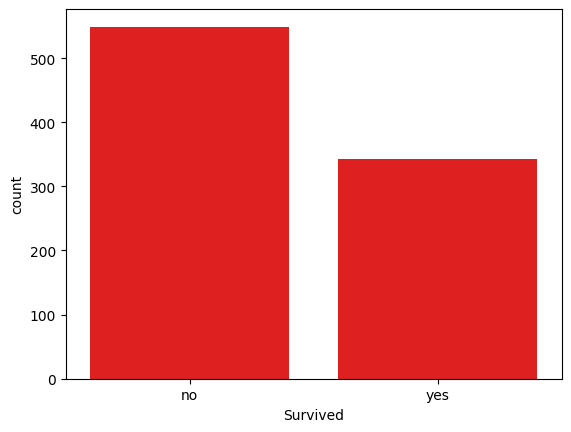

,count
Survived,
no,61.616162
yes,38.383838


In [ ]:
# count plot
sns.countplot(data = df, x = 'Survived',color = 'red')
plt.show()
# percentage distribution

(df['Survived'].value_counts() / len(df) ) * 100



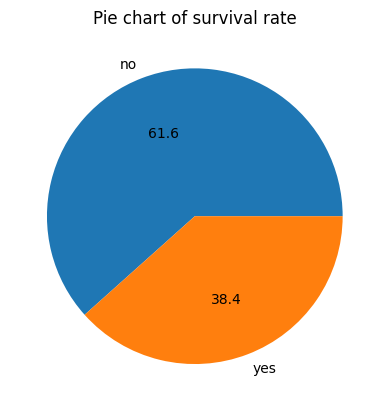

In [ ]:
#pie chart
survived_count =  df['Survived'].value_counts()
survived_label = df['Survived'].unique()

plt.pie(survived_count, labels = survived_label, autopct="%1.1f")
plt.title('Pie chart of survival rate')
plt.show()

From the pie chart, it can be observed that the majority of passengers, about 61.6%, could not survive, while the remaining 38.4% passengers survived.

Question 5
* Perform univariate numerical analysis on the Age column by:
* Creating a histogram
* Creating a KDE plot
* Write 2 observations from the plots.


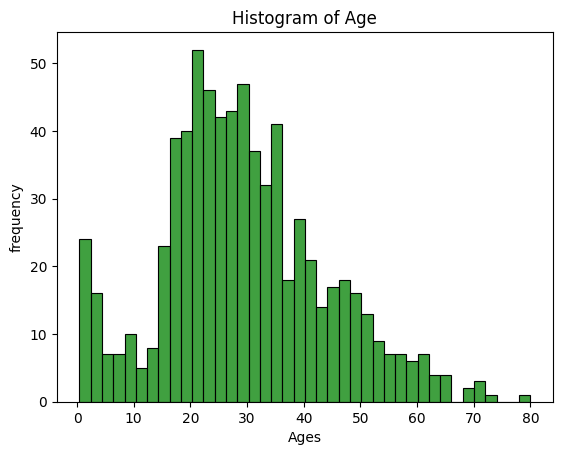

In [ ]:
# histogram
sns.histplot(df['Age'],bins=40,color='green')

plt.title('Histogram of Age')
plt.xlabel('Ages')
plt.ylabel('frequency')

plt.show()

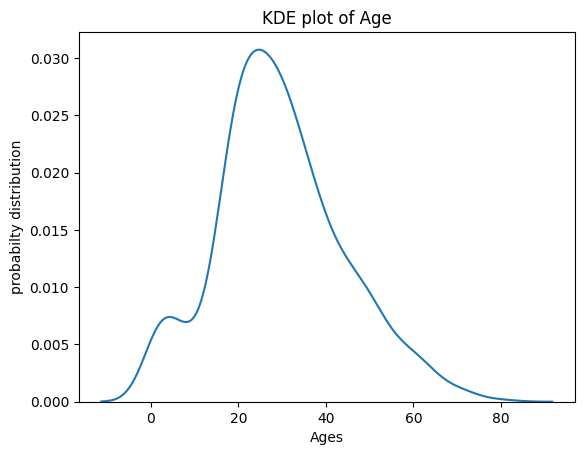

In [ ]:
#kde plot
sns.kdeplot(df['Age'])
plt.title('KDE plot of Age')
plt.xlabel('Ages')
plt.ylabel('probabilty distribution')

plt.show()

From the KDE plot, it can be observed that most passengers are between 20–40 years old. The distribution is not normal.

Since the Age distribution is not normal, using methods based on mean and Z-score may not be appropriate for handling outliers or missing values. In this case, the IQR  method would be more suitable.

Question 6
* Perform multivariate analysis between Sex and Survived using a countplot with hue.
Also calculate normalized survival ratios using groupby().
* Write 2 insights from the analysis.


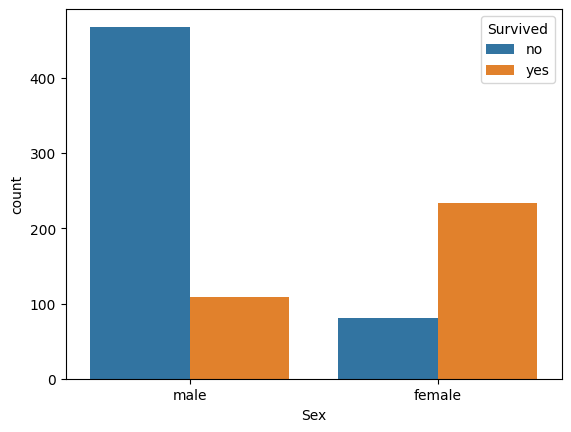

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x  = df['Sex'],hue = df['Survived'])
plt.show()
survival_ratio = df.groupby('Sex')['Survived'].value_counts(normalize=True)

print(survival_ratio)

The number of male passengers was higher than female passengers, but most males could not survive, with only 18.8% surviving. On the other hand, the number of female passengers was lower, yet around 74.2% of them survived.

Question 7
* Create a barplot showing the relationship between Pclass and Fare.
* Write 2 observations from the visualization.


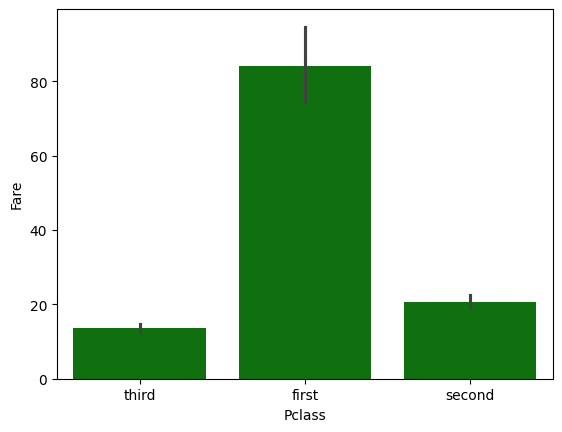

In [ ]:
sns.barplot(x=df['Pclass'],y=df['Fare'],color = 'green')
plt.show()

From the bar plot, it can be observed that first-class passengers paid the highest average fare, which was above 80. Second-class passengers paid an average fare slightly above 20, while third-class passengers paid less than 20 on average.

Question 8
* Create a KDE plot to compare the Age distribution of survived and non-survived passengers.
* Write 2 insights from the graph.


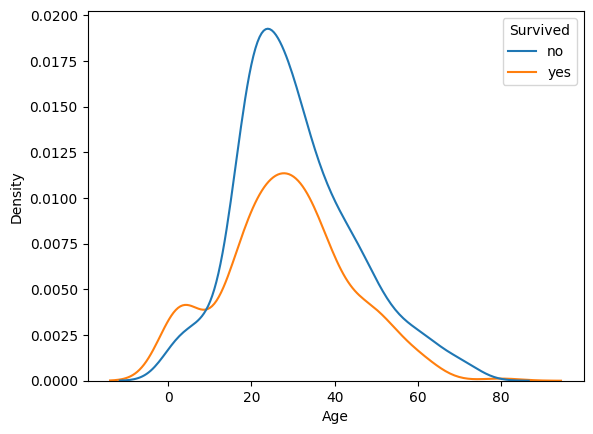

In [ ]:
sns.kdeplot(data = df , x ='Age', hue ='Survived')
plt.show()

From the KDE plot, it can be observed that most passengers were between 20–40 years old, and a large number of them survived. Passengers below 1 year of age also had a good survival rate, while a few passengers aged above 60 survived as well.

Question 9
* Perform feature engineering and train-test split by:
* Dropping PassengerId, Name, and Ticket columns
* Separating features (X) and target (y)
* Splitting the dataset using test_size=0.2 and random_state=42
* Display the shapes of train and test datasets.


In [ ]:
df.drop(['PassengerId','Name','Ticket'],axis = 1, inplace =True)


In [ ]:
x = df.drop('Survived',axis = 1)


In [ ]:
y = df['Survived']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (712, 8)
y_train shape: (712,)
X_test shape: (179, 8)
y_test shape: (179,)


Question 10
* Handle missing values in the Titanic dataset by:
* Imputing missing Age values using SimpleImputer with mean strategy
* Imputing missing Embarked values using most frequent strategy
* Imputing missing Cabin values using constant strategy with "Missing"
* Finally, check whether any missing values remain.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
# Imputing missing Age values using SimpleImputer with mean strategy

age_imputer = SimpleImputer(missing_values= np.nan, strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()

# Imputing missing Embarked values using most frequent strategy
embarked_impute = SimpleImputer(missing_values= np.nan, strategy='most_frequent')

embarked_impute.fit(X_train[['Embarked']])


X_train['Embarked'] = embarked_impute.transform(X_train[['Embarked']]).ravel()

X_test['Embarked'] = embarked_impute.transform(X_test[['Embarked']]).ravel()

#Imputing missing Cabin values using constant strategy with "Missing"

cabin_imputer = SimpleImputer(missing_values= np.nan, strategy='constant',fill_value= 'Missing',add_indicator=True)

cabin_imputer.fit(X_train[['Cabin']])

X_train[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_train[['Cabin']])

X_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])


In [ ]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0


In [ ]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0
